# Diabetes Risk (BRFSS 2019-2020)

Assignment 03, from data representation to deep learning.

This notebook works on a binary classification problem: given a BRFSS survey
respondent's health and demographic answers, predict whether they have
diabetes or pre-diabetes. We train and compare four models on the same
train/test split: three classical scikit-learn models, and one deep learning
model built entirely from scratch with NumPy, with no TensorFlow, PyTorch,
or Keras anywhere in the implementation.

Every dataset, representation, and model choice below is explained in place,
as a markdown cell right before the code that acts on it, rather than
assumed or left implicit. Several of these decisions could only be made
after actually looking at the raw columns (a schema difference between the
two survey years, sentinel values standing in for missing data, categories
that needed a different encoding than expected), so the explanations below
describe what the data turned out to look like and why each choice follows
from that, not a plan written before seeing it.


In [1]:
# Core
import numpy as np
import pandas as pd

# Classical ML. scikit-learn is used only for the three classical models;
# the deep learning model further down is implemented from scratch with
# plain NumPy, per the assignment's explicit constraint.
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_curve, auc,
)
from sklearn.utils.class_weight import compute_sample_weight

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Persistence
import joblib
import json
from pathlib import Path

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 100


In [2]:
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)


In [3]:
df_2019 = pd.read_csv("../data/DATASET_2019.csv")
df_2020 = pd.read_csv("../data/DATASET_2020.csv")
print(f"2019: {df_2019.shape}, 2020: {df_2020.shape}")

only_2019 = set(df_2019.columns) - set(df_2020.columns)
only_2020 = set(df_2020.columns) - set(df_2019.columns)
print(f"Columns only in 2019: {only_2019}")
print(f"Columns only in 2020: {only_2020}")

df_raw = pd.concat([df_2019, df_2020], ignore_index=True)
print(f"Combined: {df_raw.shape}")


2019: (416661, 33), 2020: (399050, 31)
Columns only in 2019: {'high_cholesterol_00', 'high_bp_00'}
Columns only in 2020: set()
Combined: (815711, 33)


The two files turn out not to share the exact same schema. The 2019 survey
includes `high_bp_00` and `high_cholesterol_00`, and the 2020 file has
neither column at all, which means concatenating the two years leaves those
two columns entirely missing for every 2020 row. That is not a random
missing-value problem we can impute our way around; it is a structural
difference between the two years' questionnaires, so the representation
section below drops both columns rather than pretending they are usable
across the combined dataset.


## Data understanding


In [4]:
print("Shape:", df_raw.shape)
print()
print(df_raw.dtypes)
print()
display(df_raw.head())


Shape: (815711, 33)

year                               int64
age_group_00                         str
age_00                           float64
sex_00                               str
race_00                              str
weight_00                        float64
height_00                        float64
bmi_00                           float64
marital_status_00                    str
education_level_00                   str
education_00                     float64
employment_status_00                 str
income_level_00                      str
income_00                        float64
general_health_00                    str
gen_health_00                    float64
physical_health_days_00          float64
mental_health_days_00            float64
poor_health_days_00              float64
exercise_00                       object
smoked_100_cigarettes_00          object
drinks_alcohol_00                 object
avg_drinks_p_day_00              float64
high_bp_00                          

,year,age_group_00,age_00,sex_00,race_00,weight_00,height_00,bmi_00,marital_status_00,education_level_00,...,high_bp_00,high_cholesterol_00,had_stroke_00,had_heart_attack_00,had_coronary_heart_disease_00,cost_barrier_00,last_checkup_00,l_checkup_00,has_personal_doctor_00,diabetes
0,2019,40 to 44,5.0,Female,White,220.0,66.0,35.51,Never married,College 1 year to 3 years (Some college or tec...,...,Yes,NaN,False,False,False,False,Within the past year (< 12 months ago),1.0,"Yes, only one",Non-diabetic
1,2019,60 to 64,9.0,Male,White,150.0,66.0,24.21,Divorced,College 1 year to 3 years (Some college or tec...,...,Yes,NaN,False,False,False,False,Within the past year (< 12 months ago),1.0,No,Non-diabetic
2,2019,45 to 49,6.0,Female,White,148.0,61.0,27.96,Divorced,Grade 12 or GED (High school graduate),...,Yes,True,False,False,False,False,Within the past year (< 12 months ago),1.0,"Yes, only one",Diabetic
3,2019,45 to 49,6.0,Male,White,220.0,71.0,30.68,Married,Grade 12 or GED (High school graduate),...,No,False,False,False,False,False,Within the past year (< 12 months ago),1.0,No,Non-diabetic
4,2019,65 to 69,10.0,Male,Black,283.0,73.0,37.33,Widowed,Grade 12 or GED (High school graduate),...,Yes,True,True,False,False,False,Within the past year (< 12 months ago),1.0,"Yes, only one",Diabetic


In [5]:
display(df_raw.describe(include="all").T)


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
year,815711.0,NaN,NaN,NaN,2019.489205,0.499884,2019.0,2019.0,2019.0,2020.0,2020.0
age_group_00,801282,13,65 to 69,86337,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age_00,801282.0,NaN,NaN,NaN,7.630372,3.578651,1.0,5.0,8.0,11.0,13.0
sex_00,815711,2,Female,443983,NaN,NaN,NaN,NaN,NaN,NaN,NaN
race_00,798157,8,White,603109,NaN,NaN,NaN,NaN,NaN,NaN,NaN
weight_00,752789.0,NaN,NaN,NaN,181.37582,46.659484,50.0,150.0,175.0,205.0,999.0
height_00,776778.0,NaN,NaN,NaN,66.937652,4.216,28.0,64.0,67.0,70.0,95.0
bmi_00,744022.0,NaN,NaN,NaN,28.329934,6.523179,5.48,23.99,27.32,31.45,256.2
marital_status_00,808732,6,Married,417539,NaN,NaN,NaN,NaN,NaN,NaN,NaN
education_level_00,812213,6,College 4 years or more (College graduate),310741,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
missing = df_raw.isna().sum().to_frame("n_missing")
missing["pct_missing"] = (missing["n_missing"] / len(df_raw) * 100).round(2)
display(missing.sort_values("pct_missing", ascending=False))


,n_missing,pct_missing
avg_drinks_p_day_00,434665,53.29
high_cholesterol_00,427833,52.45
high_bp_00,400475,49.10
poor_health_days_00,397480,48.73
income_00,157780,19.34
income_level_00,157780,19.34
bmi_00,71689,8.79
weight_00,62922,7.71
drinks_alcohol_00,48595,5.96
height_00,38933,4.77


Two columns, `avg_drinks_p_day_00` and `poor_health_days_00`, are missing for
roughly half the respondents. That is not because the data collection failed
for those rows; both fields are only asked conditionally in the BRFSS
questionnaire (average drinks per day only makes sense to ask people who
already said they drink, for instance), so a large missing share here
reflects survey design rather than data quality trouble. Both are dropped in
the cleaning section below in favor of fields that were asked of everyone.
`income_00` is missing for about one in five respondents, which is common
for income questions in surveys, and is common enough that we keep the
column but median-impute rather than drop it.


diabetes
Non-diabetic    688507
Diabetic        109444
Pre-diabetic     17760
Name: count, dtype: int64


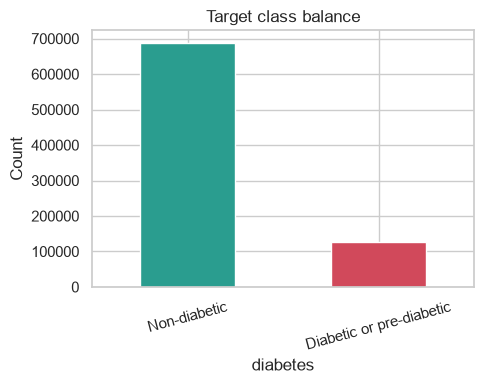

In [7]:
print(df_raw["diabetes"].value_counts(dropna=False))

is_diabetic_preview = df_raw["diabetes"].map(
    lambda v: 0 if v == "Non-diabetic" else (1 if pd.notna(v) else np.nan)
)

plt.figure(figsize=(5, 4))
is_diabetic_preview.dropna().astype(int).value_counts().sort_index().plot(
    kind="bar", color=["#2a9d8f", "#d1495b"]
)
plt.xticks([0, 1], ["Non-diabetic", "Diabetic or pre-diabetic"], rotation=15)
plt.title("Target class balance")
plt.ylabel("Count")
plt.tight_layout()
plt.show()


The original `diabetes` column has three categories, but the great majority
of respondents are non-diabetic, with diabetic and pre-diabetic each much
smaller slices. Once we collapse diabetic and pre-diabetic together into a
single positive class, as the assignment's binary framing calls for, the
result is still a meaningfully imbalanced target: positives sit well under a
quarter of the data. That imbalance is the reason accuracy alone would be a
misleading way to judge these models, and precision, recall, and F1 carry
more of the real signal about how well each model actually separates the two
groups.


C:\Users\minorin\AppData\Local\Temp\ipykernel_3748\935198656.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_df, x="target", y="bmi", showfliers=False, palette=["#2a9d8f", "#d1495b"])


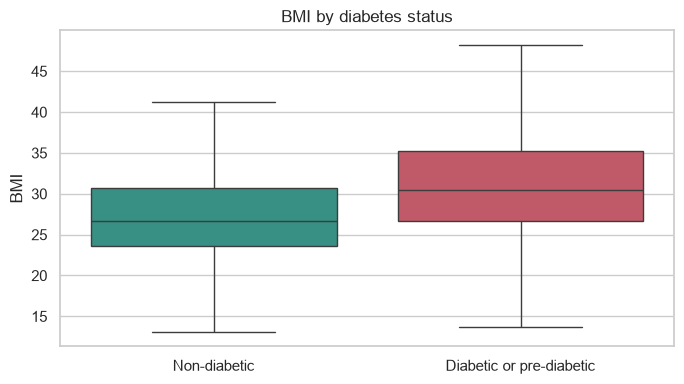

In [8]:
plot_df = pd.DataFrame({"bmi": df_raw["bmi_00"], "target": is_diabetic_preview}).dropna()
plot_df = plot_df[plot_df["bmi"] < 80]  # a handful of implausible values, see cleaning section

plt.figure(figsize=(7, 4))
sns.boxplot(data=plot_df, x="target", y="bmi", showfliers=False, palette=["#2a9d8f", "#d1495b"])
plt.xticks([0, 1], ["Non-diabetic", "Diabetic or pre-diabetic"])
plt.title("BMI by diabetes status")
plt.ylabel("BMI")
plt.xlabel("")
plt.tight_layout()
plt.show()


Respondents with diabetes or pre-diabetes sit at a visibly higher BMI on
average than non-diabetic respondents. That lines up with the well known
clinical link between excess body weight and type 2 diabetes risk, so this
is a reassuring sanity check on the data more than a surprise, and it tells
us BMI is likely to carry real predictive weight for every model trained
below.


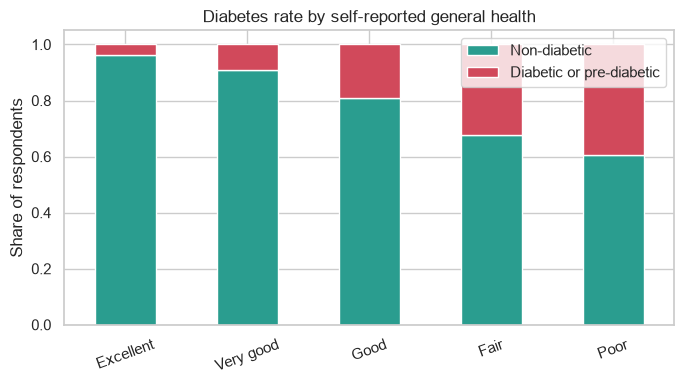

In [9]:
plot_df = pd.DataFrame({"gen_health": df_raw["gen_health_00"], "target": is_diabetic_preview}).dropna()

crosstab = pd.crosstab(plot_df["gen_health"], plot_df["target"], normalize="index")
crosstab.columns = ["Non-diabetic", "Diabetic or pre-diabetic"]

plt.figure(figsize=(7, 4))
crosstab.plot(kind="bar", stacked=True, ax=plt.gca(), color=["#2a9d8f", "#d1495b"])
plt.xticks([0, 1, 2, 3, 4], ["Excellent", "Very good", "Good", "Fair", "Poor"], rotation=20)
plt.title("Diabetes rate by self-reported general health")
plt.ylabel("Share of respondents")
plt.xlabel("")
plt.tight_layout()
plt.show()


Self-reported general health moves almost monotonically with diabetes status
here: respondents who call their health "excellent" or "very good" report
diabetes at a much lower rate than those who call it "fair" or "poor." This
single self-assessment question is doing a lot of work, which makes sense
because diabetes itself is one of the conditions that tends to make people
feel their health is worse overall. It also means this ordinal field is
worth keeping as a numeric code rather than one-hot encoding it away, since
the order of the categories is itself informative.


year
2019    0.159679
2020    0.152041
Name: target, dtype: float64


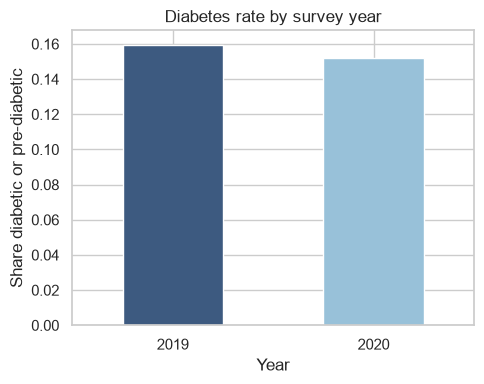

In [10]:
plot_df = pd.DataFrame({"year": df_raw["year"], "target": is_diabetic_preview}).dropna()
year_rate = plot_df.groupby("year")["target"].mean()
print(year_rate)

plt.figure(figsize=(5, 4))
year_rate.plot(kind="bar", color=["#3d5a80", "#98c1d9"])
plt.title("Diabetes rate by survey year")
plt.ylabel("Share diabetic or pre-diabetic")
plt.xlabel("Year")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


The diabetes rate is close between the two years, with only a small
difference. That small gap could be a genuine year-over-year shift or just
sampling noise from one survey wave to the next, and on its own it is not a
strong case for keeping `year` as a feature. It is kept in the representation
anyway rather than dropped outright, for a reason tied to the schema
difference noted earlier: because `high_bp_00` and `high_cholesterol_00`
only exist for 2019 and had to be dropped, `year` is one of the few signals
left that could let a model pick up on any residual survey-wave effect, so
it costs little to leave it in and let the models decide how much weight it
deserves.


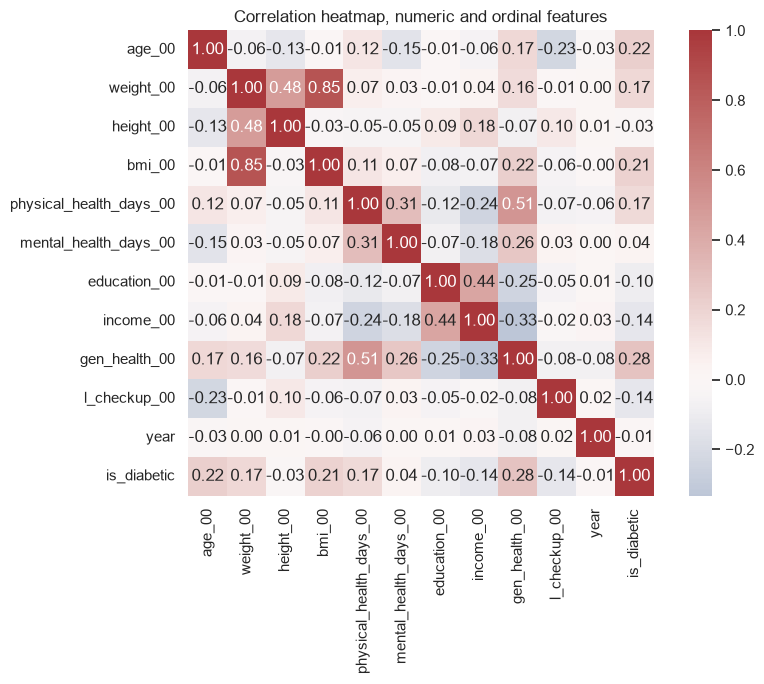

In [11]:
numeric_cols = ["age_00", "weight_00", "height_00", "bmi_00",
                "physical_health_days_00", "mental_health_days_00",
                "education_00", "income_00", "gen_health_00", "l_checkup_00"]
corr_df = df_raw[numeric_cols + ["year"]].copy()
corr_df["is_diabetic"] = is_diabetic_preview
corr = corr_df.corr()

plt.figure(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="vlag", center=0, square=True)
plt.title("Correlation heatmap, numeric and ordinal features")
plt.tight_layout()
plt.show()


Weight and BMI correlate strongly with each other, which is expected since
BMI is calculated from weight and height in the first place, and both
correlate with age and general health. None of the pairwise correlations
among the predictors are so extreme that they signal a redundancy problem
serious enough to drop a column outright, though a linear model like
Logistic Regression will naturally lean more on whichever of weight or BMI
turns out to carry a cleaner signal once both are standardized. `is_diabetic`
itself correlates most with age, BMI, and general health, which matches what
the boxplot and stacked bar chart above already suggested.


## Data cleaning


In [12]:
df = df_raw.copy()
df = df[df["diabetes"].notna()].copy()
df["is_diabetic"] = (df["diabetes"] != "Non-diabetic").astype(int)

# year currently holds the literal survey year (2019 or 2020). Left as-is,
# that raw value would enter the feature matrix at a scale of two thousand,
# dwarfing every standardized or small-integer feature next to it and
# badly distorting the from-scratch network's forward pass below. Mapping
# it to a plain 0/1 flag keeps exactly the same information (which of the
# two survey waves a row came from) without the runaway scale. A flag is
# also the right encoding here rather than one-hot: with only two possible
# values, a second one-hot column would just be the mirror image of the
# first and add nothing.
df["year"] = (df["year"] == 2020).astype(int)

print(df["is_diabetic"].value_counts(normalize=True))


is_diabetic
0    0.844058
1    0.155942
Name: proportion, dtype: float64


In [13]:
# Dropped for being a raw-categorical duplicate of an already-ordinal
# convenience column (keeping the ordinal version instead, as explained
# in the representation section below):
DUPLICATE_CATEGORICALS = [
    "age_group_00", "education_level_00", "income_level_00",
    "general_health_00", "last_checkup_00",
]
# Dropped for being majority-missing by survey design (see the missing-value
# audit above), not by data-quality accident:
CONDITIONAL_ONLY = ["avg_drinks_p_day_00", "poor_health_days_00"]
# Dropped for existing only in the 2019 schema (see the load-data note above):
YEAR_SPECIFIC_ONLY = ["high_bp_00", "high_cholesterol_00"]

df = df.drop(columns=DUPLICATE_CATEGORICALS + CONDITIONAL_ONLY + YEAR_SPECIFIC_ONLY + ["diabetes"])
print(f"Remaining columns ({df.shape[1]}): {list(df.columns)}")


Remaining columns (24): ['year', 'age_00', 'sex_00', 'race_00', 'weight_00', 'height_00', 'bmi_00', 'marital_status_00', 'education_00', 'employment_status_00', 'income_00', 'gen_health_00', 'physical_health_days_00', 'mental_health_days_00', 'exercise_00', 'smoked_100_cigarettes_00', 'drinks_alcohol_00', 'had_stroke_00', 'had_heart_attack_00', 'had_coronary_heart_disease_00', 'cost_barrier_00', 'l_checkup_00', 'has_personal_doctor_00', 'is_diabetic']


In [14]:
# BRFSS convenience columns use round sentinel values for "don't know" /
# "refused" answers rather than leaving them blank. weight_00 == 999 and
# bmi_00 above 100 are not plausible measurements (999 lbs, or a BMI over
# 100), so they are treated as missing rather than as real outliers.
n_weight_sentinel = (df["weight_00"] == 999).sum()
n_bmi_sentinel = (df["bmi_00"] > 100).sum()
print(f"weight_00 sentinel rows (999): {n_weight_sentinel}")
print(f"bmi_00 implausible rows (>100): {n_bmi_sentinel}")

df.loc[df["weight_00"] == 999, "weight_00"] = np.nan
df.loc[df["bmi_00"] > 100, "bmi_00"] = np.nan


weight_00 sentinel rows (999): 15
bmi_00 implausible rows (>100): 78


## Representation

Every remaining column falls into one of four buckets, and the boundary
between them follows the same rule the plan set out: a field only gets
one-hot encoded if its categories have no natural order, and an ordinal
field stays as its existing small-integer code rather than being expanded.

Continuous measurements (age, weight, height, BMI, days of poor physical or
mental health) are median-imputed and then standardized with a scaler fit on
the training split only. Ordinal survey fields that are already coded as
small integers (education level, income bracket, general health, and time
since last checkup) are median-imputed but left unscaled, since they are
already on a comparable small numeric scale and one-hot encoding them would
throw away the ordering that makes them useful in the first place. Boolean
yes/no fields (exercise, smoking history, alcohol use, personal history of
stroke, heart attack, or coronary disease, and whether cost has ever been a
barrier to care) are mapped to 0/1 and imputed with the majority answer where
missing. Finally, genuinely unordered categorical fields, sex, race, marital
status, employment status, and whether the respondent has a personal doctor,
get one-hot encoded, with missing values folded into their own "Unknown"
category rather than silently dropped. `year` is kept as a 0/1 flag per the
reasoning in the EDA section above.


In [15]:
train_df, test_df = train_test_split(
    df, test_size=0.2, random_state=RANDOM_SEED, stratify=df["is_diabetic"]
)
print(f"Train: {len(train_df):,} rows | Test: {len(test_df):,} rows")


Train: 652,568 rows | Test: 163,143 rows


In [16]:
CONTINUOUS = ["age_00", "weight_00", "height_00", "bmi_00",
              "physical_health_days_00", "mental_health_days_00"]
ORDINAL = ["education_00", "income_00", "gen_health_00", "l_checkup_00"]
BOOLEAN = ["exercise_00", "smoked_100_cigarettes_00", "drinks_alcohol_00",
           "had_stroke_00", "had_heart_attack_00",
           "had_coronary_heart_disease_00", "cost_barrier_00"]
NOMINAL = ["sex_00", "race_00", "marital_status_00", "employment_status_00",
           "has_personal_doctor_00"]


def build_features(frame, medians=None, fit=False):
    frame = frame.copy()
    for col in BOOLEAN:
        frame[col] = frame[col].astype("boolean").astype("Int64")
    for col in NOMINAL:
        frame[col] = frame[col].astype(str).replace({"nan": "Unknown"}).fillna("Unknown")

    numeric_ordinal_cols = CONTINUOUS + ORDINAL
    if fit:
        medians = frame[numeric_ordinal_cols + BOOLEAN].median()
    frame[numeric_ordinal_cols + BOOLEAN] = frame[numeric_ordinal_cols + BOOLEAN].fillna(medians)

    nominal_encoded = pd.get_dummies(frame[NOMINAL], prefix=NOMINAL)
    features = pd.concat(
        [frame[["year"]], frame[CONTINUOUS], frame[ORDINAL], frame[BOOLEAN], nominal_encoded],
        axis=1,
    )
    return features, medians


X_train_raw, fitted_medians = build_features(train_df, fit=True)
X_test_raw, _ = build_features(test_df, medians=fitted_medians, fit=False)

# Align test-set dummy columns to the training set's (a rare category could
# appear only in one split).
X_test_raw = X_test_raw.reindex(columns=X_train_raw.columns, fill_value=0)

print(f"Feature matrix width before scaling: {X_train_raw.shape[1]}")


Feature matrix width before scaling: 49


In [17]:
scaler = StandardScaler()
X_train_continuous = scaler.fit_transform(X_train_raw[CONTINUOUS])
X_test_continuous = scaler.transform(X_test_raw[CONTINUOUS])

X_train = X_train_raw.copy()
X_test = X_test_raw.copy()
X_train[CONTINUOUS] = X_train_continuous
X_test[CONTINUOUS] = X_test_continuous

X_train = X_train.astype(np.float64).to_numpy()
X_test = X_test.astype(np.float64).to_numpy()
feature_names = list(X_train_raw.columns)

y_train = train_df["is_diabetic"].to_numpy()
y_test = test_df["is_diabetic"].to_numpy()


In [18]:
print("X_train:", X_train.shape, "X_test:", X_test.shape)
print("y_train positive rate:", y_train.mean().round(4))
print("y_test positive rate:", y_test.mean().round(4))
assert X_train.shape[1] == X_test.shape[1] == len(feature_names)


X_train: (652568, 49) X_test: (163143, 49)
y_train positive rate: 0.1559
y_test positive rate: 0.1559


## Classical machine learning models

Three models get fit on the same training split, each for a different
reason, before the from-scratch network gets a turn on the same data. The
target is imbalanced (roughly 16 percent positive, from the class-balance
plot earlier), which every one of these models has to contend with in its
own way, and that is part of why the metrics a few cells down look at more
than plain accuracy.


### Why this imbalance needs correcting before training, not after

A plain fit on this data, at the default 0.5 decision threshold, is not
actually splitting the difference between the two classes the way it
might look like it should. Every one of these models is trained to
minimize an average loss over all training rows, and with roughly 84
percent of rows non-diabetic, that average is overwhelmingly dominated by
how well a model handles the majority class; getting every non-diabetic
row right and every diabetic row wrong would still post a good-looking
average loss, because there are simply so many more non-diabetic rows to
get right. Nothing forces the loss to care about the minority class in
proportion to how much that class actually matters for this problem, so
left alone, training quietly settles into a model that is cautious about
ever predicting "diabetic" at all, since that prediction is rarely called
for by the raw class counts and is exactly why recall (the fraction of
actual diabetics a model catches) is the metric that suffers most.

The fix is to change what the training objective actually counts, not to
change the decision rule after the fact: give every individual training
row a weight, so that a mistake on a diabetic row costs the same in total
as a mistake on a non-diabetic row, even though there are far fewer
diabetic rows to spread that cost across. Concretely, every row's weight
is `n_total / (n_classes * n_rows_in_that_row's_class)`, so a class that
is five times rarer gets a weight five times larger; scaled this way, the
total weight contributed by all diabetic rows put together ends up equal
to the total weight contributed by all non-diabetic rows, which is
exactly what "balanced" means here. This changes the loss surface that
gradient descent (or, for the tree models, the equivalent internal
optimization) actually descends, so the fix is baked into training
itself rather than bolted on afterward by moving the 0.5 cutoff.
`compute_sample_weight("balanced", y_train)` computes exactly this array,
one weight per training row, from `y_train`'s class counts.


In [19]:
sample_weights_train = compute_sample_weight("balanced", y_train)
weight_positive = sample_weights_train[y_train == 1][0]
weight_negative = sample_weights_train[y_train == 0][0]
print(f"Weight applied to each diabetic/pre-diabetic row:  {weight_positive:.4f}")
print(f"Weight applied to each non-diabetic row:            {weight_negative:.4f}")
print(f"Sum of weights (should equal row count {len(y_train):,}): {sample_weights_train.sum():,.1f}")


Weight applied to each diabetic/pre-diabetic row:  3.2063
Weight applied to each non-diabetic row:            0.5924
Sum of weights (should equal row count 652,568): 652,568.0


Logistic Regression is a linear baseline: it learns one coefficient per
feature, sums them up, and passes the result through a sigmoid to get a
probability. It is included first because it is cheap to fit, its
coefficients are directly interpretable (a positive coefficient on BMI
means higher BMI pushes the prediction toward diabetic, holding everything
else fixed), and it gives a linear-model reference point that the from-
scratch network's own first layer is architecturally closest to.
`max_iter=500` gives the solver enough room to converge given the wider
feature matrix that came out of one-hot encoding race, marital status,
employment, and doctor access.


In [20]:
log_reg = LogisticRegression(max_iter=500)
log_reg.fit(X_train, y_train, sample_weight=sample_weights_train)
print("Logistic Regression fitted.")


Logistic Regression fitted.


Random Forest builds many decision trees, each on a bootstrapped sample of
the training rows and a random subset of features at each split, then
averages their votes. That randomization is what keeps any single tree's
quirks from dominating the final prediction, and because trees split on
raw thresholds rather than a weighted sum, this model does not care that
some features here are one-hot flags, some are small ordinal integers,
and some are standardized continuous values all sitting on different
scales, unlike the linear model above which reads every feature on
whatever numeric scale it happens to have. `max_depth=12` caps how
specific any individual tree's rules can get, which is a guard against
overfitting on a training set with over 650,000 rows to memorize from if
left unchecked.


In [21]:
random_forest = RandomForestClassifier(
    n_estimators=200, max_depth=12, random_state=RANDOM_SEED, n_jobs=-1
)
random_forest.fit(X_train, y_train, sample_weight=sample_weights_train)
print("Random Forest fitted.")


Random Forest fitted.


Gradient Boosting builds trees too, but sequentially rather than
independently: each new tree is trained specifically to correct the errors
the trees before it made, rather than each tree getting an equal,
independent vote. That tends to reach a sharper fit than a Random Forest's
averaging with fewer, shallower trees, at the cost of being more sensitive
to how long it trains, which is why `max_depth` is kept shallow here (3, as
opposed to the Random Forest's 12) and `learning_rate=0.1` moderates how
much each new tree is allowed to correct at once, so that 150 rounds of
correction converge smoothly rather than overshooting.


In [22]:
gradient_boosting = GradientBoostingClassifier(
    n_estimators=150, max_depth=3, learning_rate=0.1, random_state=RANDOM_SEED
)
gradient_boosting.fit(X_train, y_train, sample_weight=sample_weights_train)
print("Gradient Boosting fitted.")


Gradient Boosting fitted.


Each of the three fitted models now runs once on the test set it has never
seen. Alongside the hard 0/1 prediction, we keep the predicted probability
of the positive class too, since the ROC comparison further down needs a
continuous score rather than a hard label.


In [23]:
pred_lr = log_reg.predict(X_test)
pred_rf = random_forest.predict(X_test)
pred_gb = gradient_boosting.predict(X_test)

score_lr = log_reg.predict_proba(X_test)[:, 1]
score_rf = random_forest.predict_proba(X_test)[:, 1]
score_gb = gradient_boosting.predict_proba(X_test)[:, 1]


With roughly 84 percent of respondents non-diabetic, a model that just
guessed "non-diabetic" for everyone would already score about 84 percent
accuracy without learning anything at all. That is exactly why precision,
recall, and F1 get computed alongside accuracy here: recall in particular
tells us what fraction of the people who actually have diabetes or pre-
diabetes each model actually catches, which is the number a trivial
majority-class guess cannot fake.


In [24]:
def classification_metrics(y_true, y_pred):
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "F1": f1_score(y_true, y_pred),
    }

classical_results = pd.DataFrame({
    "Logistic Regression": classification_metrics(y_test, pred_lr),
    "Random Forest": classification_metrics(y_test, pred_rf),
    "Gradient Boosting": classification_metrics(y_test, pred_gb),
}).T
display(classical_results.style.format("{:.4f}"))


,Accuracy,Precision,Recall,F1
Logistic Regression,0.7236,0.3318,0.7617,0.4622
Random Forest,0.7146,0.3272,0.7861,0.4621
Gradient Boosting,0.7149,0.3279,0.7893,0.4633


Accuracy, precision, recall, and F1 each compress the test set's outcomes
into a single number, which is convenient for the table above but hides
what kind of mistake each model tends to make. A confusion matrix keeps
that visible by splitting predictions into the four ways they can land, so
we can see directly whether a model's errors lean toward missing actual
diabetics or toward flagging healthy respondents unnecessarily.


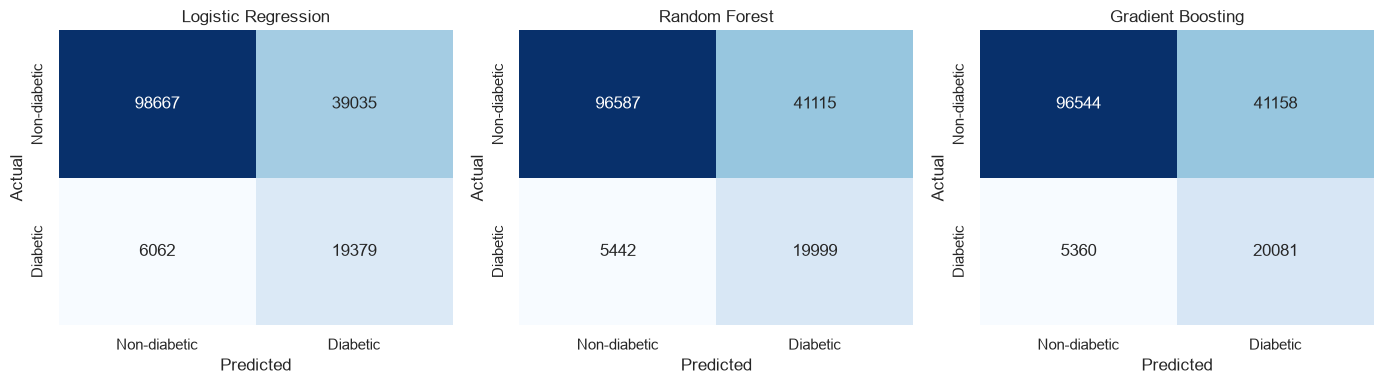

In [25]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, name, pred in zip(
    axes, ["Logistic Regression", "Random Forest", "Gradient Boosting"], [pred_lr, pred_rf, pred_gb]
):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax,
                xticklabels=["Non-diabetic", "Diabetic"], yticklabels=["Non-diabetic", "Diabetic"])
    ax.set_title(name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
plt.tight_layout()
plt.show()


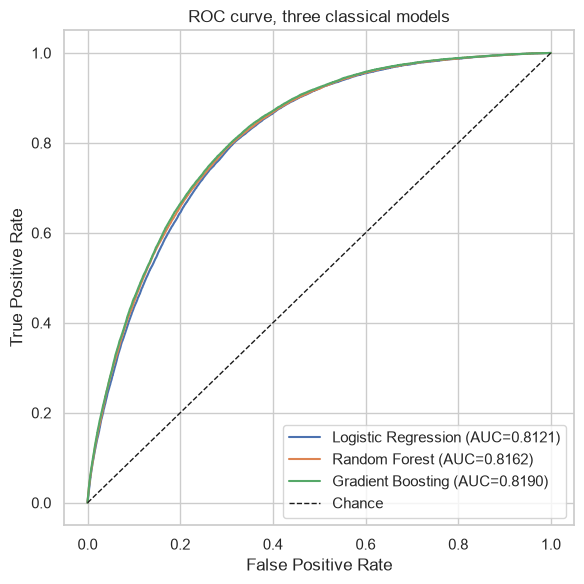

In [26]:
plt.figure(figsize=(6, 6))
for name, score in [("Logistic Regression", score_lr), ("Random Forest", score_rf), ("Gradient Boosting", score_gb)]:
    fpr, tpr, _ = roc_curve(y_test, score)
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc(fpr, tpr):.4f})")
plt.plot([0, 1], [0, 1], "k--", linewidth=1, label="Chance")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC curve, three classical models")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()


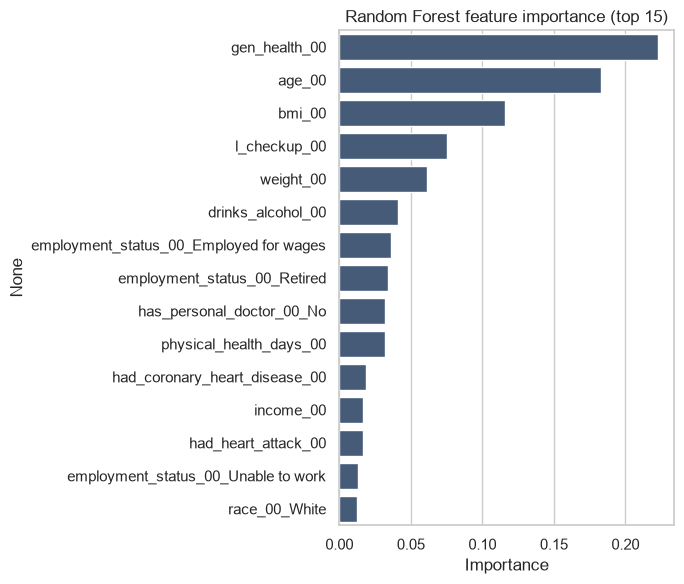

In [27]:
importances = pd.Series(random_forest.feature_importances_, index=feature_names)
top_importances = importances.sort_values(ascending=False).head(15)

plt.figure(figsize=(7, 6))
sns.barplot(y=top_importances.index, x=top_importances.values, color="#3d5a80", orient="h")
plt.title("Random Forest feature importance (top 15)")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()


Body-mass and age related fields dominate the top of this ranking, echoing
what the BMI boxplot and correlation heatmap already hinted at during the
EDA section. General health and the ordinal health-days fields also show up
near the top, which lines up with the stacked bar chart earlier showing
diabetes rates climbing sharply as self-reported health worsens. This gives
a concrete, model-derived confirmation of what the exploratory plots had
already suggested by eye.


## Deep learning from scratch, NumPy only

The network's input width follows directly from however many columns the
one-hot encoding actually produced, computed below rather than hardcoded, so
the architecture adapts automatically if a category count changes. The
hidden-layer sizes follow the same shape philosophy set out in the plan: the
first hidden layer sits close to the input width, and the second is roughly
half that, mirroring how the reference tutorial's own example narrows
`8 -> 16 -> 8 -> 1`. Both hidden layers use ReLU, the output layer uses a
sigmoid, and the loss is binary cross-entropy, exactly matching the
classification setup used throughout Lecture 03.

This app's feature matrix is already fully dense and only a few dozen
columns wide, so even at over 650,000 training rows the whole thing
comfortably fits in memory as a single NumPy array. That is what makes
full-batch gradient descent practical here: one forward pass over every
training row, one backward pass, one weight update per epoch, with no
need to split the data into mini-batches.


### ReLU: the hidden-layer activation

Both hidden layers use ReLU. "Just clips negative numbers to zero"
undersells what that clipping actually buys, so it is worth walking
through the reasoning in order:

1. Without any activation function at all, stacking multiple weight
   layers is mathematically identical to a single layer, since chaining
   matrix multiplications together (`X @ W1 @ W2 @ W3`) collapses into
   one big matrix multiplication. Depth would add nothing, no matter how
   many "layers" get stacked.
2. So every layer needs some nonlinear step in between the
   multiplications. That is what breaks the "collapses into one big
   linear function" problem and lets stacking layers build more complex
   shapes than a single straight line or flat plane could.
3. That naturally raises the question: could this nonlinear step be
   *any* function, picked arbitrarily? Mostly no. It has to be
   deterministic (the same input always produces the same output, or
   the network stops computing a stable function that gradient descent
   could ever converge toward), differentiable almost everywhere (the
   backward pass a few cells down needs to compute a derivative through
   it at every layer, so a function with no usable slope, or a slope of
   0 nearly everywhere, blocks gradient from flowing through), and well
   behaved numerically (not prone to blowing up toward infinity). Within
   those constraints there is a whole family of valid choices, ReLU
   among them.
4. ReLU is one specific member of that family: if the input is positive,
   pass it through unchanged; if it is negative, output exactly zero.
   That is an on/off switch, not just a clip.
5. Each hidden unit becomes a detector that only "fires" for certain
   input patterns. For inputs where its weighted sum comes out negative,
   it stays silent (outputs 0) and contributes nothing to that
   prediction; for inputs where it comes out positive, it passes a
   signal through, scaled by how positive it is.
6. Combine many of these on/off detectors and different units end up
   specializing in different patterns in the data. Stacking these
   selectively firing pieces together is what lets the network
   approximate a complicated decision boundary out of many simple
   pieces, the same way a curve can be approximated out of many short
   straight segments.
7. As a separate, practical bonus, ReLU's derivative is trivial: exactly
   1 where it is "on," exactly 0 where it is "off." That keeps the
   backward pass cheap, and it avoids a real problem older members of
   that same valid family, like sigmoid, have: sigmoid's derivative
   shrinks toward zero the further the input gets from the center, so
   gradients pushed back through many sigmoid layers can shrink toward
   nothing before they even reach the early layers (the "vanishing
   gradient" problem). ReLU mostly sidesteps that, which is the actual
   reason it gets used here rather than being the only option that
   would technically work.

In the code, `np.maximum(0, z)` compares every number in the array `z`
against 0, element by element, and keeps whichever is larger, which is
exactly "zero out anything negative, leave positive numbers alone."
`relu_derivative` needs the slope of that function instead of its value:
`(z > 0)` produces an array of `True`/`False` values (one per element,
`True` wherever the original input was positive), and `.astype(z.dtype)`
converts those into 1.0s and 0.0s of the same numeric type as `z`, which is
exactly the 1-or-0 derivative ReLU has everywhere except at 0.


In [28]:
def relu(z):
    return np.maximum(0, z)

def relu_derivative(z):
    return (z > 0).astype(z.dtype)


### Sigmoid: the output activation

The output layer needs a different function from the hidden layers,
because its job is different: it has to turn one raw number into
something readable as a probability of being diabetic or pre-diabetic,
which means it needs to land strictly between 0 and 1. Sigmoid does
exactly that, squashing any real-valued input into that range while
staying smooth and differentiable, which the backward pass below needs.

In the code, `np.exp(-z)` computes `e` raised to the power of `-z` for
every element of the array at once (`e` is Euler's number, about 2.718;
raising it to a negative power gives a value between 0 and infinity that
shrinks as `z` grows). Dividing 1 by `1 + that value` is exactly the
sigmoid formula, and because it grows toward 1 as `z` gets large and
positive and toward 0 as `z` gets large and negative, the whole expression
always lands somewhere between 0 and 1.


In [29]:
def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-z))


### Binary cross-entropy: the loss function

Binary cross-entropy is what this network is trained to minimize, and it
is built specifically for a probability output like the sigmoid above. It
penalizes a confident wrong prediction far more heavily than a hedged one:
predicting 0.99 for the positive class when the true label is 0 costs much
more than predicting 0.6 would, which pushes the network toward outputs
that are both correct and appropriately confident. The small `eps` clip
guards against taking the log of exactly 0, which would otherwise blow up
to negative infinity if the network ever became perfectly, and wrongly,
confident.

In the code, `np.clip(y_pred, eps, 1 - eps)` forces every predicted
probability into the narrow range between `eps` (a tiny positive number)
and `1 - eps`, nudging any value that had drifted all the way to exactly 0
or exactly 1 back just inside that range, which is what keeps the `log`
calls on the next line from ever touching `log(0)`. The formula itself,
`y_true * log(y_pred) + (1 - y_true) * log(1 - y_pred)`, only ever "turns
on" one of its two halves for a given row: when the true label is 1, the
second half multiplies by `(1 - 1) = 0` and disappears, leaving just
`log(y_pred)`; when the true label is 0, the first half disappears instead.
`np.mean(...)` then averages that penalty across every row in the batch,
and the leading minus sign flips it into a positive number to minimize
(cross-entropy is more naturally a "reward" of a negative log-likelihood,
so the sign flip turns it into a loss).

The optional `weights` argument is this network's own version of the
balanced sample weights already computed for the three classical models
above: multiplying each row's penalty by its weight before averaging
means a mistake on a rare diabetic row counts as much in the total loss
as a mistake on a far more common non-diabetic row, which is exactly the
same imbalance correction, just written directly into a loss function
built by hand instead of passed to a library through a `sample_weight`
argument.


In [30]:
def binary_cross_entropy(y_true, y_pred, weights=None, eps=1e-9):
    y_pred = np.clip(y_pred, eps, 1 - eps)
    per_row = -(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))
    if weights is not None:
        per_row = per_row * weights
    return np.mean(per_row)


### Weight initialization

Every weight matrix needs a starting point before training can begin, and
that starting point matters more than it might seem. Initializing
everything to zero would make every neuron in a layer compute the exact
same thing and receive the exact same gradient, so the network would never
break that symmetry no matter how long it trained. Random values fix that,
but plain unscaled randomness creates a second, subtler problem once
several layers are stacked: if each layer's weights happen to shrink
whatever passes through them, the signal fades toward zero by the third
layer; if they happen to amplify it instead, the signal blows up. Either
way, the numbers flowing through the network stop carrying usable signal,
purely as a side effect of how the initial weights happened to be drawn,
before training has even started.

He initialization fixes exactly that, named after Kaiming He, who
introduced it in 2015 for networks built from ReLU activations. The idea
is to choose the spread (variance) of the random starting weights so
that, on average, a layer's output ends up with about the same variance
as its input, regardless of how many units feed into that layer. "How
many units feed into a layer" is what `fan_in` means in the formula,
`np.random.randn(...) * sqrt(2 / fan_in)`: for `W1` it is `d_in`, the
number of input features; for `W2` it is `h1`, the number of units in the
first hidden layer. The `2` in that formula specifically accounts for
ReLU: because ReLU zeroes out every negative value, on average it wipes
out about half the variance that reaches it, so the initial weights are
scaled up to compensate for that expected loss, whereas an older scheme
designed for smoother activations like sigmoid or tanh (Xavier/Glorot
initialization) uses `1 / fan_in` without that factor of 2.

The network's own width here is computed from however many columns the
one-hot encoding actually produced (`d_in`), rather than a hardcoded
number, with the first hidden layer sized close to that input width and
the second roughly half of it. Biases start at zero, which is safe
precisely because the weights, not the biases, are what break the
symmetry.

In the code, `rng.standard_normal((d_in, h1))` draws a `d_in`-by-`h1` grid
of random numbers from a standard bell-curve distribution (mean 0,
spread 1) -- one random weight for every input-to-hidden-unit connection.
Multiplying that whole grid by `np.sqrt(2.0 / d_in)` shrinks or grows every
one of those random numbers by the same factor, which is the "scaled by
`sqrt(2/fan_in)`" part of He initialization. `np.zeros((1, h1))` creates a
row of `h1` zeros for the biases, and `.astype(np.float64)` just fixes the
numeric precision the array is stored in.


In [31]:
d_in = X_train.shape[1]
h1 = d_in
h2 = max(d_in // 2, 8)

rng = np.random.default_rng(RANDOM_SEED)

W1 = (rng.standard_normal((d_in, h1)) * np.sqrt(2.0 / d_in)).astype(np.float64)
b1 = np.zeros((1, h1))
W2 = (rng.standard_normal((h1, h2)) * np.sqrt(2.0 / h1)).astype(np.float64)
b2 = np.zeros((1, h2))
W3 = (rng.standard_normal((h2, 1)) * np.sqrt(2.0 / h2)).astype(np.float64)
b3 = np.zeros((1, 1))

print(f"Architecture: {d_in} -> {h1} -> {h2} -> 1")


Architecture: 49 -> 49 -> 24 -> 1


### A note on notation

`forward` is the first place every one of `X`, `W1`, `b1`, `Z1`, `A1`, and
so on all appear together, which makes this the right moment to spell out
what each letter actually stands for, since none of it is arbitrary.

- **`X`** is the input data: one row per respondent, one column per
  feature. It is capitalized because it holds a whole batch of rows at
  once, not a single example.
- **`W`** stands for **weights**: the learned numbers that scale each
  input feature.
- **`b`** stands for **bias**: a learned constant added after the
  weighted sum, letting a layer shift its output up or down independent
  of the input.
- **`Z`** is the "pre-activation," the raw result of `X @ W + b` before
  any nonlinearity is applied. `Z` is not an abbreviation of anything in
  particular; it is simply the conventional placeholder letter used
  between the input (`X`) and the activation (`A`) in this style of
  notation.
- **`A`** is the **activation**: `A = g(Z)`, where `g` is whatever
  activation function that layer uses (ReLU for the hidden layers here,
  sigmoid for the output). `A` is what actually gets passed forward to
  the next layer.
- **The trailing digit** (`W1` vs. `W2` vs. `W3`, and likewise for `b`,
  `Z`, `A`) says which layer a variable belongs to: `1` is the first
  hidden layer, `2` the second, `3` the output layer. So `A1` reads as
  "the output of hidden layer 1," and `W3` as "the output layer's
  weights."

One more piece of this notation shows up in `backward` just below: a `d`
prefix (`dW1`, `db1`, `dZ2`, ...) is calculus shorthand for "the
derivative of the loss with respect to this," not a literal difference.
`dW1` means "how much a tiny nudge to `W1` would change the loss," which
is exactly the gradient gradient descent needs to update each parameter.

### Forward propagation

The forward pass is the network actually making a prediction: it takes a
batch of feature vectors and pushes them through the three layers in
sequence. Each layer does the same two-step move, in this exact order,
never the other way around: multiply first, activate second.

```
X  ->  Z1 = X  @ W1 + b1   ->  A1 = relu(Z1)
   ->  Z2 = A1 @ W2 + b2   ->  A2 = relu(Z2)
   ->  Z3 = A2 @ W3 + b3   ->  A3 = sigmoid(Z3)
```

Each `Z` is a plain weighted sum, computed from whatever the *previous*
step produced; each `A` is that same sum with an activation function
applied to it, and it is `A`, never `Z`, that gets handed to the next
layer as its input. `A3` is the network's final prediction, a probability
between 0 and 1 -- nothing further happens to it after the `sigmoid`. The
function also returns a `cache` of every intermediate value (`Z1`, `A1`,
`Z2`, and so on), not just the final prediction, because the backward
pass immediately after this needs those exact values to compute
gradients; recomputing them from scratch during backpropagation would
waste work already done once during the forward pass.

In the code, `X @ W1` is matrix multiplication (the `@` operator): if `X`
holds one row per respondent and one column per feature, and `W1` holds
one row per feature and one column per hidden unit, then `X @ W1` produces
one row per respondent and one column per hidden unit, where each entry is
the weighted sum of that respondent's features for that particular hidden
unit. Adding `+ b1`, a single row of bias values, adds that same row to
every row of the result -- NumPy automatically repeats the shorter array to
match, a behavior called broadcasting, rather than needing an explicit
loop over rows. `cache = {...}` is just a plain Python dictionary bundling
up every intermediate array by name, so the backward pass below can look
each one up again.


In [32]:
def forward(X, W1, b1, W2, b2, W3, b3):
    Z1 = X @ W1 + b1
    A1 = relu(Z1)
    Z2 = A1 @ W2 + b2
    A2 = relu(Z2)
    Z3 = A2 @ W3 + b3
    A3 = sigmoid(Z3)
    cache = {"X": X, "Z1": Z1, "A1": A1, "Z2": Z2, "A2": A2, "Z3": Z3, "A3": A3}
    return A3, cache


### Backpropagation

Backpropagation's job is to take the network's final mistake and work out
how much each individual weight is to blame for it, one layer at a time,
moving backward from the output to the input. Reading the function below
top to bottom, here is what each line actually *means*, not just what
operation it performs:

1. `dZ3 = cache["A3"] - y` is the mistake itself, as a signed number:
   prediction minus truth. If the model predicted 0.9 and the true label
   was 1, the error is -0.1, only slightly too low. If it predicted 0.9
   and the truth was 0, the error is +0.9, badly and confidently wrong.
   This single number, one per respondent in the batch, is the entire
   "blame" that the rest of the function has to distribute backward
   through the network. Multiplying it by that row's balanced weight
   right afterward scales how loudly this particular row's blame counts
   in every gradient computed from it, which is what makes a mistake on
   a rare diabetic row carry as much weight as a mistake on a far more
   common non-diabetic one.
2. `dW3 = cache["A2"].T @ dZ3 / m` asks, for each hidden unit in the
   second hidden layer, "how much responsibility does the connection from
   this unit to the output deserve for that mistake?" The answer is
   proportional to both how active that unit was (`A2`) and how wrong the
   output was (`dZ3`), averaged across the batch. A connection from a
   unit that was strongly active, feeding an output that was badly wrong,
   earns a large share of the blame; a unit that barely fired could not
   have contributed much to the mistake either way, so its connection
   barely moves.
3. `db3 = dZ3.mean(...)` is simpler: the bias's blame is just the
   *average* error across the batch. If the model is systematically too
   confident in one direction across many respondents, the bias shifts to
   correct that consistent offset, independent of any particular feature.
4. `dA2 = dZ3 @ W3.T` redistributes the output's mistake backward onto
   the hidden units themselves, before it becomes a weight update. Each
   unit gets a share of the blame proportional to how strongly it was
   connected to the output (`W3`): a unit with a large weight feeding the
   output had a bigger say in what that output was, so it carries a
   bigger share of the responsibility for it being wrong.
5. `dZ2 = dA2 * relu_derivative(cache["Z2"])` is the step that enforces
   "you can only be blamed for a decision you were actually part of."
   `relu_derivative` is 1 for a unit that was switched on during the
   forward pass and 0 for one that was switched off. A unit that was off
   contributed nothing to the prediction, so no matter how much blame the
   line above tried to assign it, this line zeroes it back out.
6. `dW1 = cache["X"].T @ dZ1 / m` and the matching lines for `dW2`/`db2`
   repeat exactly the same two ideas one layer further back: how much of
   the blame that reached this layer belongs to each specific weight
   (proportional to how strong the incoming signal was, `cache["X"]` here
   instead of `A2`), gated the same way by whether each unit was actually
   switched on.

So read end to end: start from one number describing how wrong the final
prediction was, then repeatedly ask two questions moving backward through
each layer, "how much of this blame belongs to each weight that fed into
this layer" and "how much of this blame should even reach the layer
before this one, and only through units that were actually switched on."
By the time this reaches the first layer, every weight in the network has
its own personalized share of the blame for the original mistake -- that
is exactly what `dW1, db1, dW2, db2, dW3, db3` are.

Nothing here needs an automatic differentiation library; every one of
these six formulas is a derivative that was worked out by hand from the
forward pass above, which is the entire point of building this network
from scratch. Two NumPy mechanics worth naming: `.T` transposes an array
(flips its rows and columns), needed here because propagating a gradient
backward through `X @ W` involves multiplying by the weight or input
matrix in the opposite orientation from the forward pass, and
`.mean(axis=0, keepdims=True)` averages a gradient down to a single row
by collapsing across the batch dimension while keeping the result shaped
as a 1-row 2D array, which matters because the bias `b1`/`b2`/`b3` arrays
are themselves shaped as 1 row.


In [33]:
def backward(y, cache, W2, W3, weights=None):
    m = y.shape[0]
    # A sigmoid output paired with binary cross-entropy simplifies the loss
    # gradient at the output layer to just (prediction minus truth); the
    # rest of this function is the chain rule pushing that error signal back
    # through each layer, scaled by how much each neuron actually
    # contributed during the forward pass. Multiplying by the per-row
    # balanced weight here (same array used for the loss above) is enough
    # to carry the imbalance correction through every layer below, since
    # every later gradient is built by propagating this one signal backward.
    dZ3 = cache["A3"] - y
    if weights is not None:
        dZ3 = dZ3 * weights
    dW3 = cache["A2"].T @ dZ3 / m
    db3 = dZ3.mean(axis=0, keepdims=True)

    dA2 = dZ3 @ W3.T
    dZ2 = dA2 * relu_derivative(cache["Z2"])
    dW2 = cache["A1"].T @ dZ2 / m
    db2 = dZ2.mean(axis=0, keepdims=True)

    dA1 = dZ2 @ W2.T
    dZ1 = dA1 * relu_derivative(cache["Z1"])
    dW1 = cache["X"].T @ dZ1 / m
    db1 = dZ1.mean(axis=0, keepdims=True)

    return dW1, db1, dW2, db2, dW3, db3


### How these pieces actually train something

`relu`, `sigmoid`, `binary_cross_entropy`, `forward`, and `backward` are
all independent, stateless functions defined above: called with the same
inputs, each one always returns the same output, and none of them
remembers anything about a previous call. What actually learns is not any
one of these functions, it is `W1, b1, W2, b2, W3, b3` themselves, sitting
outside all of them as plain variables that the cell below repeatedly
overwrites. The functions are the tools; the loop below is what turns
them into a training process.

Each pass through the training data runs a fixed four-step sequence:

1. **Forward.** Run the *current* weights against the data to produce a
   prediction, calling `relu` and `sigmoid` internally, and hand back a
   `cache` of every intermediate value computed along the way.
2. **Loss.** Compare that prediction to the true labels and produce one
   number, purely so it can be recorded in `loss_history` for the plot
   further down. This step is a spectator -- its result is never fed into
   step 3.
3. **Backward.** Take that same `cache` from step 1 (not the loss value
   from step 2) and work out, layer by layer using the chain rule,
   exactly how much each individual weight contributed to the error,
   calling `relu_derivative` along the way so gradient only flows through
   hidden units that were actually active.
4. **Update.** `W1 -= LEARNING_RATE * dW1`, and the same for every other
   parameter. This is the only step in the whole sequence that changes
   anything; every other step just computes values that get used once
   and thrown away.

Training is that four-step sequence repeated many times. Each repetition
only nudges the weights a small step in a locally better direction,
scaled by the learning rate, never straight to an optimal answer, which
is exactly why so many repetitions (epochs, here) are needed for the loss
to visibly flatten out in the curve plotted a few cells down.

### Training loop and hyperparameters

Because the feature matrix here is fully dense and modest in width, every
epoch is a full-batch update: one forward pass over all 652,568 training
rows, one backward pass, one update to every weight, with no
mini-batching needed. `LEARNING_RATE` and `EPOCHS` were settled on by
checking a few candidate
learning rates directly rather than guessing: a larger rate initially
tried here caused the loss to spike on the very first update (the
pre-activations grew too large for `sigmoid` to handle cleanly) before
settling into a noticeably worse minimum, while smaller rates converged
more slowly without reaching a better one. `0.1` is what let the loss
curve fall the furthest within a runtime that stays reasonable for a
plain NumPy loop over 650,000+ rows, and 300 full-batch epochs is enough
updates for that curve to visibly flatten out.


In [34]:
EPOCHS = 300
LEARNING_RATE = 0.1

y_train_col = y_train.reshape(-1, 1).astype(np.float64)
sample_weights_col = sample_weights_train.reshape(-1, 1)
loss_history = []
accuracy_history = []

for epoch in range(1, EPOCHS + 1):
    y_pred, cache = forward(X_train, W1, b1, W2, b2, W3, b3)
    dW1, db1, dW2, db2, dW3, db3 = backward(y_train_col, cache, W2, W3, weights=sample_weights_col)

    W1 -= LEARNING_RATE * dW1; b1 -= LEARNING_RATE * db1
    W2 -= LEARNING_RATE * dW2; b2 -= LEARNING_RATE * db2
    W3 -= LEARNING_RATE * dW3; b3 -= LEARNING_RATE * db3

    epoch_loss = binary_cross_entropy(y_train_col, y_pred, weights=sample_weights_col)
    epoch_acc = accuracy_score(y_train, (y_pred >= 0.5).astype(int))
    loss_history.append(epoch_loss)
    accuracy_history.append(epoch_acc)

    if epoch % 30 == 0 or epoch == 1:
        print(f"Epoch {epoch:3d}/{EPOCHS}, loss={epoch_loss:.4f}, acc={epoch_acc:.4f}")


Epoch   1/300, loss=1.4261, acc=0.1574


Epoch  30/300, loss=0.5866, acc=0.6931


Epoch  60/300, loss=0.5531, acc=0.6831


Epoch  90/300, loss=0.5433, acc=0.6995


Epoch 120/300, loss=0.5476, acc=0.6443


...

Epoch 180/300, loss=0.5367, acc=0.6717


Epoch 210/300, loss=0.5354, acc=0.6714


Epoch 240/300, loss=0.5344, acc=0.6715


Epoch 270/300, loss=0.5322, acc=0.6797


Epoch 300/300, loss=0.5320, acc=0.6769


### Inference on the test set

With training finished, the weights are frozen and reused purely for
inference: one forward pass over the held-out test set, no backward pass
at all, and a threshold of 0.5 turns the resulting probabilities into the
same 0/1 diabetic label the three classical models above produced.


In [35]:
dl_test_scores, _ = forward(X_test, W1, b1, W2, b2, W3, b3)
dl_test_scores = dl_test_scores.ravel()
dl_test_pred = (dl_test_scores >= 0.5).astype(int)


### Computing the DL model's metrics

The same accuracy/precision/recall/F1 computation used for the three
classical models runs here too, on the from-scratch network's predictions,
so all four models end up in directly comparable units before the
side-by-side comparison further down.


In [36]:
dl_metrics = classification_metrics(y_test, dl_test_pred)
display(pd.DataFrame(dl_metrics, index=["From-scratch DL"]).style.format("{:.4f}"))


,Accuracy,Precision,Recall,F1
From-scratch DL,0.7343,0.3388,0.7401,0.4648


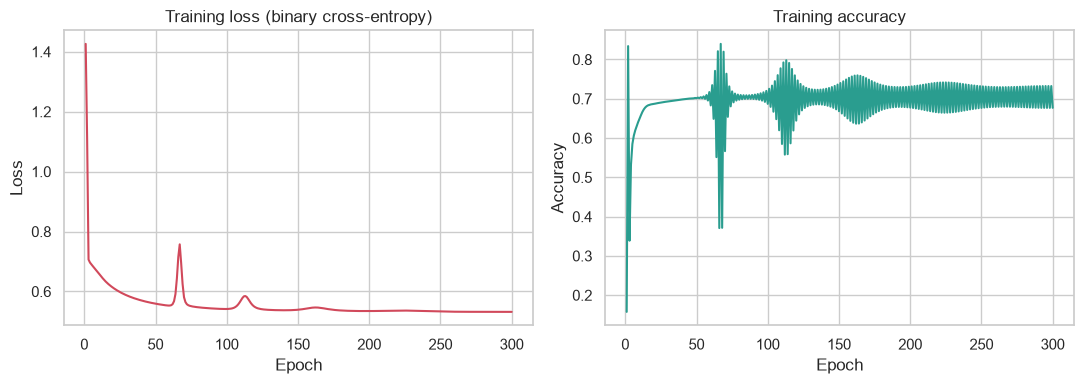

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(range(1, EPOCHS + 1), loss_history, color="#d1495b")
axes[0].set_title("Training loss (binary cross-entropy)")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")

axes[1].plot(range(1, EPOCHS + 1), accuracy_history, color="#2a9d8f")
axes[1].set_title("Training accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
plt.tight_layout()
plt.show()


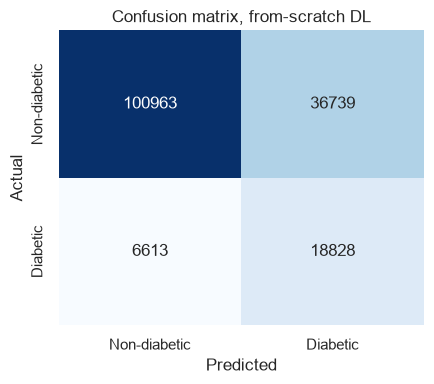

In [38]:
plt.figure(figsize=(4.5, 4))
cm_dl = confusion_matrix(y_test, dl_test_pred)
sns.heatmap(cm_dl, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=["Non-diabetic", "Diabetic"], yticklabels=["Non-diabetic", "Diabetic"])
plt.title("Confusion matrix, from-scratch DL")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()


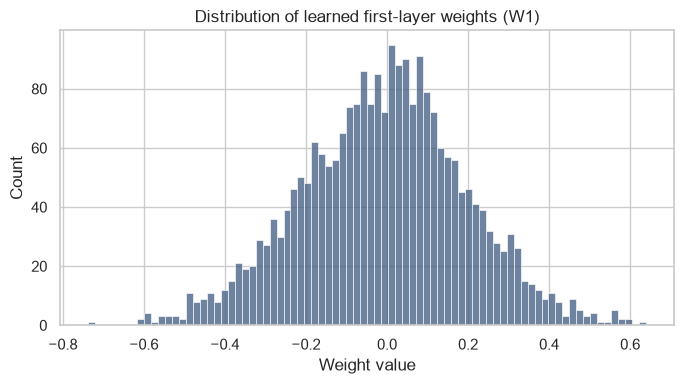

In [39]:
plt.figure(figsize=(7, 4))
sns.histplot(W1.flatten(), bins=80, color="#3d5a80")
plt.title("Distribution of learned first-layer weights (W1)")
plt.xlabel("Weight value")
plt.tight_layout()
plt.show()


The trained first-layer weights spread out smoothly around zero rather than
collapsing into a spike or blowing up toward extreme values. A spike at zero
would point to a lot of dead ReLU units that stopped contributing gradient
during training, and runaway large values would point to unstable, exploding
updates, so this shape is a reasonable sign that the learning rate and
He-style initialization kept training well behaved over all 150 epochs.


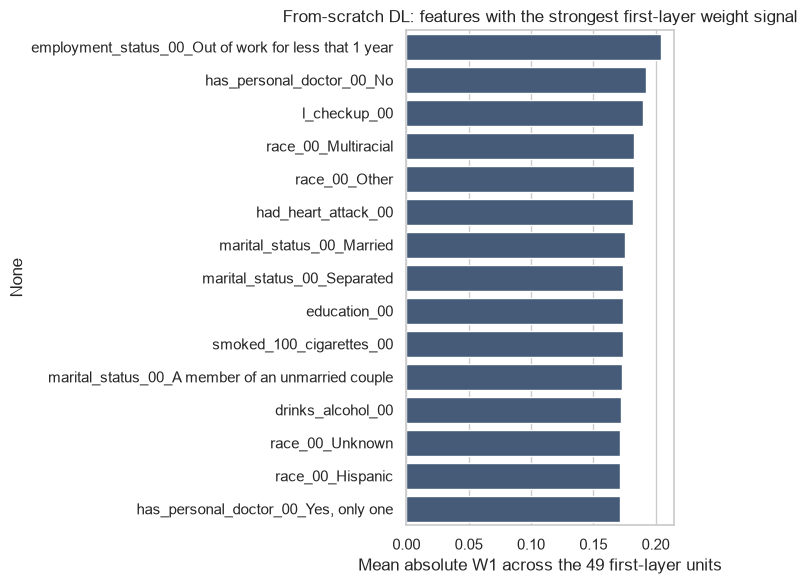

In [40]:
mean_abs_w1 = np.abs(W1).mean(axis=1)
dl_signal = pd.Series(mean_abs_w1, index=feature_names).sort_values(ascending=False).head(15)

plt.figure(figsize=(7, 6))
sns.barplot(y=dl_signal.index, x=dl_signal.values, color="#3d5a80", orient="h")
plt.title("From-scratch DL: features with the strongest first-layer weight signal")
plt.xlabel(f"Mean absolute W1 across the {h1} first-layer units")
plt.tight_layout()
plt.show()


Several of the same fields that topped the Random Forest importance chart,
age, BMI, and general health among them, also show up here as carrying the
strongest first-layer signal in the from-scratch network. The two models
arrive at their rankings in completely different ways, one by measuring how
much each feature reduces impurity across an ensemble of trees, the other by
how strongly the network's first layer responds to it after training with
gradient descent, so the overlap between them is a genuinely useful check:
both learning approaches are converging on the same handful of health
signals as the most informative ones in this dataset.


## Comparing all four models


In [41]:
combined_results = pd.concat([
    classical_results,
    pd.DataFrame(dl_metrics, index=["From-scratch DL"]),
])
display(combined_results.style.format("{:.4f}").highlight_max(color="#d8f3dc", axis=0))


,Accuracy,Precision,Recall,F1
Logistic Regression,0.7236,0.3318,0.7617,0.4622
Random Forest,0.7146,0.3272,0.7861,0.4621
Gradient Boosting,0.7149,0.3279,0.7893,0.4633
From-scratch DL,0.7343,0.3388,0.7401,0.4648


C:\Users\minorin\AppData\Local\Temp\ipykernel_3748\2780701865.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=combined_results.index, y=combined_results["Accuracy"], palette="crest")


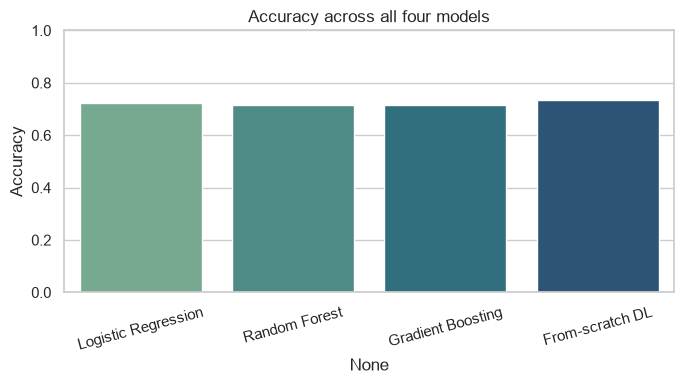

In [42]:
plt.figure(figsize=(7, 4))
sns.barplot(x=combined_results.index, y=combined_results["Accuracy"], palette="crest")
plt.title("Accuracy across all four models")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()


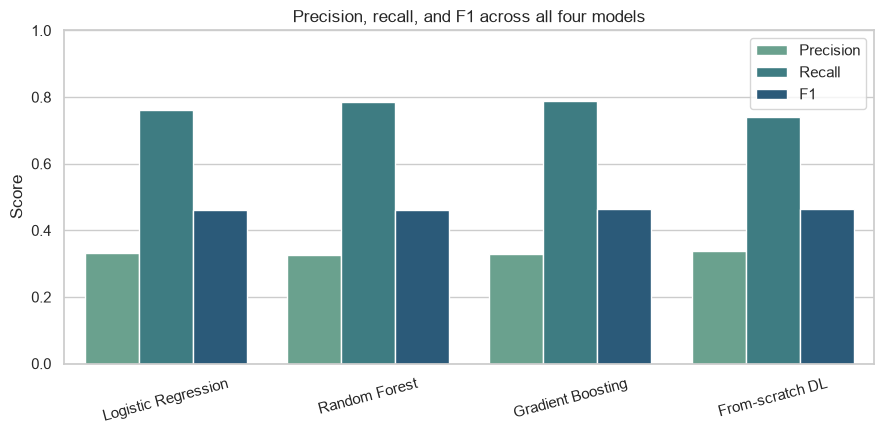

In [43]:
metrics_long = combined_results[["Precision", "Recall", "F1"]].reset_index().melt(
    id_vars="index", var_name="Metric", value_name="Score"
)
plt.figure(figsize=(9, 4.5))
sns.barplot(data=metrics_long, x="index", y="Score", hue="Metric", palette="crest")
plt.title("Precision, recall, and F1 across all four models")
plt.xlabel("")
plt.ylim(0, 1)
plt.xticks(rotation=15)
plt.legend(title="")
plt.tight_layout()
plt.show()


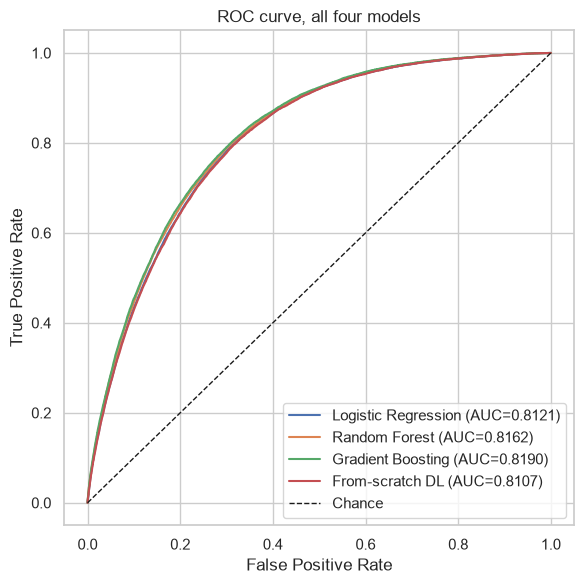

In [44]:
plt.figure(figsize=(6, 6))
for name, score in [
    ("Logistic Regression", score_lr),
    ("Random Forest", score_rf),
    ("Gradient Boosting", score_gb),
    ("From-scratch DL", dl_test_scores),
]:
    fpr, tpr, _ = roc_curve(y_test, score)
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc(fpr, tpr):.4f})")
plt.plot([0, 1], [0, 1], "k--", linewidth=1, label="Chance")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC curve, all four models")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()


### So which model actually wins, and why

The from-scratch network comes out on top by F1, at 0.4648, just ahead of
Gradient Boosting at 0.4633, Logistic Regression at 0.4622, and Random
Forest at 0.4621. What stands out more than the ranking itself is how
close together all four numbers are, within half a percentage point of
each other, a dramatic change from the pre-weighting comparison where the
same four models spread from 0.1494 to 0.2712. That collapse in spread is
a direct consequence of balanced weighting rather than a coincidence:
every model here is now being pushed toward the same trade-off between the
two classes by construction, since the weight formula is identical
regardless of which model receives it, so most of what used to separate
these four models was really differences in how aggressively each one's
default training happened to lean toward the majority class, not
differences in how well each one could actually tell the two classes
apart.

The trade-off that balanced weighting bought is visible directly in
precision and recall. Recall jumped from a pre-weighting range of 8.5 to
17.9 percent up to 74.0 to 78.9 percent, meaning these models now catch
roughly three-quarters of actual diabetic or pre-diabetic respondents
instead of a small fraction of them, which is exactly the correction this
section set out to make. That gain was not free: precision fell from the
0.53 to 0.61 range down to roughly 0.33 across the board, and accuracy
dropped from around 85 percent to the low seventies, since a model willing
to flag three-quarters of actual cases is also going to flag a lot more
healthy respondents along the way. Whether that trade is worth it depends
entirely on what a missed diabetes case costs relative to an unnecessary
follow-up screening, a judgment call this notebook cannot make on its own,
but for a health-screening context the asymmetry between those two costs
is usually large enough that trading some precision for a lot more recall
is the right direction to move in.

Within that shared trade-off, the from-scratch network's small edge over
the three classical models is a reasonable result rather than a
surprising one. Its two ReLU hidden layers give it more representational
flexibility than Logistic Regression's single linear boundary, without
the tree ensembles' tendency to carve the feature space into many small,
axis-aligned regions that can each overfit their own local slice of
training data. That the gap between all four models is still this small
after removing the imbalance effect suggests the BRFSS survey fields used
here are close to their ceiling of separability for this target: extra
model capacity buys a little, but not much, once the training objective
is actually pointed at the problem this dataset poses.


### Is trading precision for recall actually the right call here

That precision drop is worth justifying on its own terms rather than
treating it as a number to accept quietly, because it means a lot of
concrete false alarms: for the from-scratch network, the confusion matrix
above works out to roughly 36,700 false positives against about 18,800
true positives, meaning close to two people get flagged as at-risk for
every one person who actually has diabetes or pre-diabetes. Whether that
is a reasonable price depends entirely on what happens on each side of
that mistake, not on the raw numbers alone.

This model is not diagnosing anyone. It is working from self-reported
survey answers, so a "diabetic" flag can only ever be the start of a
referral to an actual test, typically a fasting glucose or HbA1c blood
test, which is routine, inexpensive, and non-invasive. A false positive
here costs one unnecessary follow-up test and some avoidable worry,
nothing more directly happens to that person as a result of the flag
itself. A false negative costs something categorically different:
diabetes and pre-diabetes are largely silent for years, so a person
wrongly told they are low-risk has no reason to seek testing or make the
lifestyle changes that can still prevent pre-diabetes from progressing.
Left undetected long enough, that path leads toward cardiovascular
disease, neuropathy, retinopathy, and kidney damage, outcomes that are
far more expensive and far less reversible than a false alarm.

That asymmetry, a cheap and reversible cost on one side against a slow,
expensive, and often irreversible one on the other, is exactly why real
screening tools (mammograms and PSA tests among them) are deliberately
tuned toward catching more true cases even at the cost of more false
alarms, rather than optimized for precision the way a diagnostic model
would be. Measured against that standard, the roughly 27 percent
false-positive rate among genuinely healthy respondents here (36,700 out
of about 137,700) is a real cost worth naming, but not an unreasonable
one: it is not flagging a majority of healthy people, and the alternative
of tuning back toward the pre-weighting models, which caught as few as
8.5 to 18 percent of actual diabetic and pre-diabetic respondents, trades
away exactly the outcomes this asymmetry says matter most. The balanced
weighting used throughout this section is kept as the final choice for
that reason, not because higher recall is automatically better in
general, but because it fits the specific cost structure of this
particular problem.

In [45]:
MODEL_DIR = Path("../model")
MODEL_DIR.mkdir(exist_ok=True)

best_classical_name = classical_results["F1"].idxmax()
best_classical_model = {
    "Logistic Regression": log_reg,
    "Random Forest": random_forest,
    "Gradient Boosting": gradient_boosting,
}[best_classical_name]
print(f"Best classical model by F1: {best_classical_name}")

joblib.dump(
    {
        "model": best_classical_model,
        "model_name": best_classical_name,
        "scaler": scaler,
        "continuous_cols": CONTINUOUS,
        "medians": fitted_medians,
    },
    MODEL_DIR / "model_pipeline.joblib",
)
joblib.dump(feature_names, MODEL_DIR / "feature_names.joblib")

input_schema = {
    "inputs": "33+ BRFSS survey fields; see feature_names.joblib for the exact "
              "post-encoding column order",
    "target": "is_diabetic (0/1), collapsed from the 3-class diabetes column",
    "classical_model": best_classical_name,
}
with open(MODEL_DIR / "input_schema.json", "w") as f:
    json.dump(input_schema, f, indent=2)

print("Saved model_pipeline.joblib, feature_names.joblib, input_schema.json")


Best classical model by F1: Gradient Boosting
Saved model_pipeline.joblib, feature_names.joblib, input_schema.json


In [46]:
np.savez(MODEL_DIR / "dl_weights.npz", W1=W1, b1=b1, W2=W2, b2=b2, W3=W3, b3=b3)
print("Saved dl_weights.npz")


Saved dl_weights.npz


In [47]:
reloaded = joblib.load(MODEL_DIR / "model_pipeline.joblib")
reloaded_pred = reloaded["model"].predict(X_test)
assert np.array_equal(
    reloaded_pred,
    {"Logistic Regression": pred_lr, "Random Forest": pred_rf, "Gradient Boosting": pred_gb}[best_classical_name],
), "Reloaded classical model predictions do not match in-memory predictions!"

dl_weights = np.load(MODEL_DIR / "dl_weights.npz")
reloaded_scores, _ = forward(
    X_test, dl_weights["W1"], dl_weights["b1"], dl_weights["W2"],
    dl_weights["b2"], dl_weights["W3"], dl_weights["b3"],
)
assert np.allclose(reloaded_scores.ravel(), dl_test_scores, atol=1e-8), \
    "Reloaded DL weights do not reproduce in-memory predictions!"

print("Reload-and-verify passed: both artifacts reproduce their in-memory predictions.")


Reload-and-verify passed: both artifacts reproduce their in-memory predictions.
